In [1]:
from pathlib import Path
import pandas as pd

csv_path = Path("llm_dataset_tracker - To-go-datasets.csv")
if not csv_path.exists():
    csv_path = Path("..") / csv_path

df = pd.read_csv(csv_path, skiprows=4, encoding="utf-8-sig").dropna(how="all").reset_index(drop=True)
print(f"{len(df)} rows × {len(df.columns)} columns")
df.head()


73 rows × 28 columns


,Dataset Name,Paper Title (Hyperlink the url),Authors,Institution,Year/Release Time,Venue / Publication Status,Extension format,URL(s),Availability,License,...,Domain,Dataset Generation Method,Splits Provided,Quality-verification method,Required Preprocessing,Known Issues / Bias,Model Training Relevance,My Summary (1 line),Notes – Source Claims,Notes – Verified by Me
0,Oscar Corpus Nepali,Asynchronous Pipeline for Processing Huge Corp...,NaN,NaN,NaN,NaN,.txt,https://www.kaggle.com/datasets/hsebarp/oscar-...,Publicly downloadable,NaN,...,NaN,NaN,NaN,NaN,Normalization,NaN,NaN,NaN,NaN,NaN
1,Cohere-Aya Nepali(train),Aya Dataset: An Open-Access Collection for Mul...,NaN,NaN,"Feb 11, 2024",NaN,.parquet,https://huggingface.co/datasets/CohereLabs/aya...,Publicly downloadable,Apache 2.0,...,General,NaN,NaN,NaN,"Cleaning, Deduplication, Language filtering",NaN,NaN,"language arts, cultural comprehension, and soc...",NaN,NaN
2,CC100-Nepali,Unsupervised Cross-lingual Representation Lear...,NaN,Facebook AI,2020,NaN,.txt,https://data.statmt.org/cc-100/,Publicly downloadable,MIT License,...,General,Web crawled,NaN,NaN,"Cleaning, Deduplication, Language filtering",NaN,Core,"websites, blogs, articles, and forums",NaN,NaN
3,gorkhapatra-nepali-epaper,NaN,NaN,NaN,25 July 2026,NaN,.parquet,https://huggingface.co/datasets/Aananda-giri/g...,Publicly downloadable,NaN,...,News,Human Generated,NaN,NaN,NaN,The dataset is converted using a font mapping ...,Core,NaN,Per-article text extracted from PDF e-papers p...,NaN
4,sangraha,INDICLLMSUITE: A Blueprint for Creating Pre-tr...,NaN,ai4bharat,2024,NaN,.parquet,https://huggingface.co/datasets/ai4bharat/sang...,Publicly downloadable,Creative Commons Attribution 4.0,...,NaN,Human+Model,NaN,NaN,NaN,NaN,NaN,NaN,consists of three components: Verified (data s...,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Dataset Name                     73 non-null     object 
 1   Paper Title (Hyperlink the url)  26 non-null     object 
 2   Authors                          0 non-null      float64
 3   Institution                      11 non-null     object 
 4   Year/Release Time                63 non-null     object 
 5   Venue / Publication Status       0 non-null      float64
 6   Extension format                 19 non-null     object 
 7   URL(s)                           73 non-null     object 
 8   Availability                     73 non-null     object 
 9   License                          37 non-null     object 
 10  Documentation Type               41 non-null     object 
 11  Last Verified Date               0 non-null      float64
 12  Dataset Role (LLM Lifecy

In [3]:
df.describe()

,Authors,Venue / Publication Status,Last Verified Date,Data Instance Context,Splits Provided,Quality-verification method,Notes – Verified by Me
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['Dataset Name', 'Paper Title (Hyperlink the url)', 'Authors',
       'Institution', 'Year/Release Time', 'Venue / Publication Status',
       'Extension format', 'URL(s)', 'Availability', 'License',
       'Documentation Type', 'Last Verified Date',
       'Dataset Role (LLM Lifecycle)', 'Primary Task', 'Language Coverage',
       'Script', 'Data Instance Context', 'Data Size (reported)', 'Domain',
       'Dataset Generation Method', 'Splits Provided',
       'Quality-verification method', 'Required Preprocessing',
       'Known Issues / Bias', 'Model Training Relevance',
       'My Summary (1 line)', 'Notes – Source Claims',
       'Notes – Verified by Me'],
      dtype='object')

In [5]:
# Clean text; keep the original df unchanged and missing values missing.
df_clean = df.astype("string").apply(lambda s: s.str.replace("\u00a0", " ", regex=False).str.strip())
df_clean.columns = df_clean.columns.str.strip()
df_clean = df_clean.replace(r"^\s*$", pd.NA, regex=True)

# Extract years without inventing a day/month for year-only entries.
years = df_clean["Year/Release Time"].str.extract(r"\b((?:19|20)\d{2})\b", expand=False)
df_clean["Release year"] = pd.to_numeric(years, errors="coerce").astype("Int64")

# Convert storage sizes to decimal GB; preserve original reported sizes.
size = df_clean["Data Size (reported)"].str.extract(r"^(\d+(?:\.\d+)?)\s*(B|kB|KB|MB|GB|TB|KiB|MiB|GiB|TiB)$")
units = {"B": 1, "kB": 1e3, "KB": 1e3, "MB": 1e6, "GB": 1e9, "TB": 1e12,
         "KiB": 1024, "MiB": 1024**2, "GiB": 1024**3, "TiB": 1024**4}
df_clean["Size (GB)"] = pd.to_numeric(size[0], errors="coerce") * size[1].map(units) / 1e9

# Standardize observed spelling variants and split multi-value fields.
df_clean["Script"] = df_clean["Script"].replace({"Mixed(Nepali+English)": "Mixed (Nepali + English)"})
df_clean["License"] = df_clean["License"].str.lower().replace({
    "apache 2.0": "apache-2.0", "apache-2.0 license": "apache-2.0", "mit license": "mit",
    "gpl-3.0 license": "gpl-3.0", "cc-by-sa-4.0 license": "cc-by-sa-4.0",
    "creative commons attribution 4.0": "cc-by-4.0", "cc by-sa 4.0": "cc-by-sa-4.0", "cc by-nc 4.0": "cc-by-nc-4.0"})
df_clean["Licenses"] = df_clean["License"].str.split(r"\s*[;\n]\s*")
df_clean["Preprocessing steps"] = df_clean["Required Preprocessing"].str.split(r"\s*,\s*")
df_clean["URLs"] = df_clean["URL(s)"].str.findall(r"https?://[^\s<>]+")

unparsed = df_clean["Data Size (reported)"].notna() & df_clean["Size (GB)"].isna()
print("Unparsed sizes (original text retained):", df_clean.loc[unparsed, "Data Size (reported)"].unique().tolist())
df_clean[["Dataset Name", "Release year", "Size (GB)", "Language Coverage", "Script"]].head()


Unparsed sizes (original text retained): ['30 Mb']


,Dataset Name,Release year,Size (GB),Language Coverage,Script
0,Oscar Corpus Nepali,<NA>,1.7,Nepali-only,Devanagari
1,Cohere-Aya Nepali(train),2024,0.1372,Multilingual,Mixed (Devanagari + romanized)
2,CC100-Nepali,2020,4.0,Nepali-only,<NA>
3,gorkhapatra-nepali-epaper,2026,0.572,Bilingual (Nepali-English),Mixed (Nepali + English)
4,sangraha,2024,16.9,Multilingual,Devanagari


In [6]:
# Cell 1 — Extract release year, dataset name, and reported purpose.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from textwrap import fill

# Assumes your DataFrame is named df.
data = df.rename(columns=lambda c: c.strip())
plot_df = data[
    ["Dataset Name", "Year/Release Time", "Dataset Role (LLM Lifecycle)"]
].copy()
plot_df.columns = ["Dataset", "Release", "Purpose"]

for col in plot_df.columns:
    plot_df[col] = plot_df[col].astype("string").str.strip()

missing = {"", "na", "n/a", "nan", "none", "null", "unknown",
           "not available", "not specified", "-", "—", "?"}
plot_df = plot_df.apply(lambda s: s.mask(s.str.lower().isin(missing)))

# Use the first explicit four-digit year; skip missing/unparseable values.
plot_df["Year"] = pd.to_numeric(
    plot_df["Release"].str.extract(r"\b((?:19|20)\d{2})\b", expand=False),
    errors="coerce",
)
plot_df = (
    plot_df.dropna(subset=["Dataset", "Year", "Purpose"])
    .assign(Year=lambda d: d["Year"].astype(int))
    .drop_duplicates(subset=["Dataset", "Year", "Purpose"])
    .sort_values(["Year", "Dataset"])
    .reset_index(drop=True)
)

print(f"Plotting {len(plot_df)} records with a year and reported purpose.")

Plotting 63 records with a year and reported purpose.


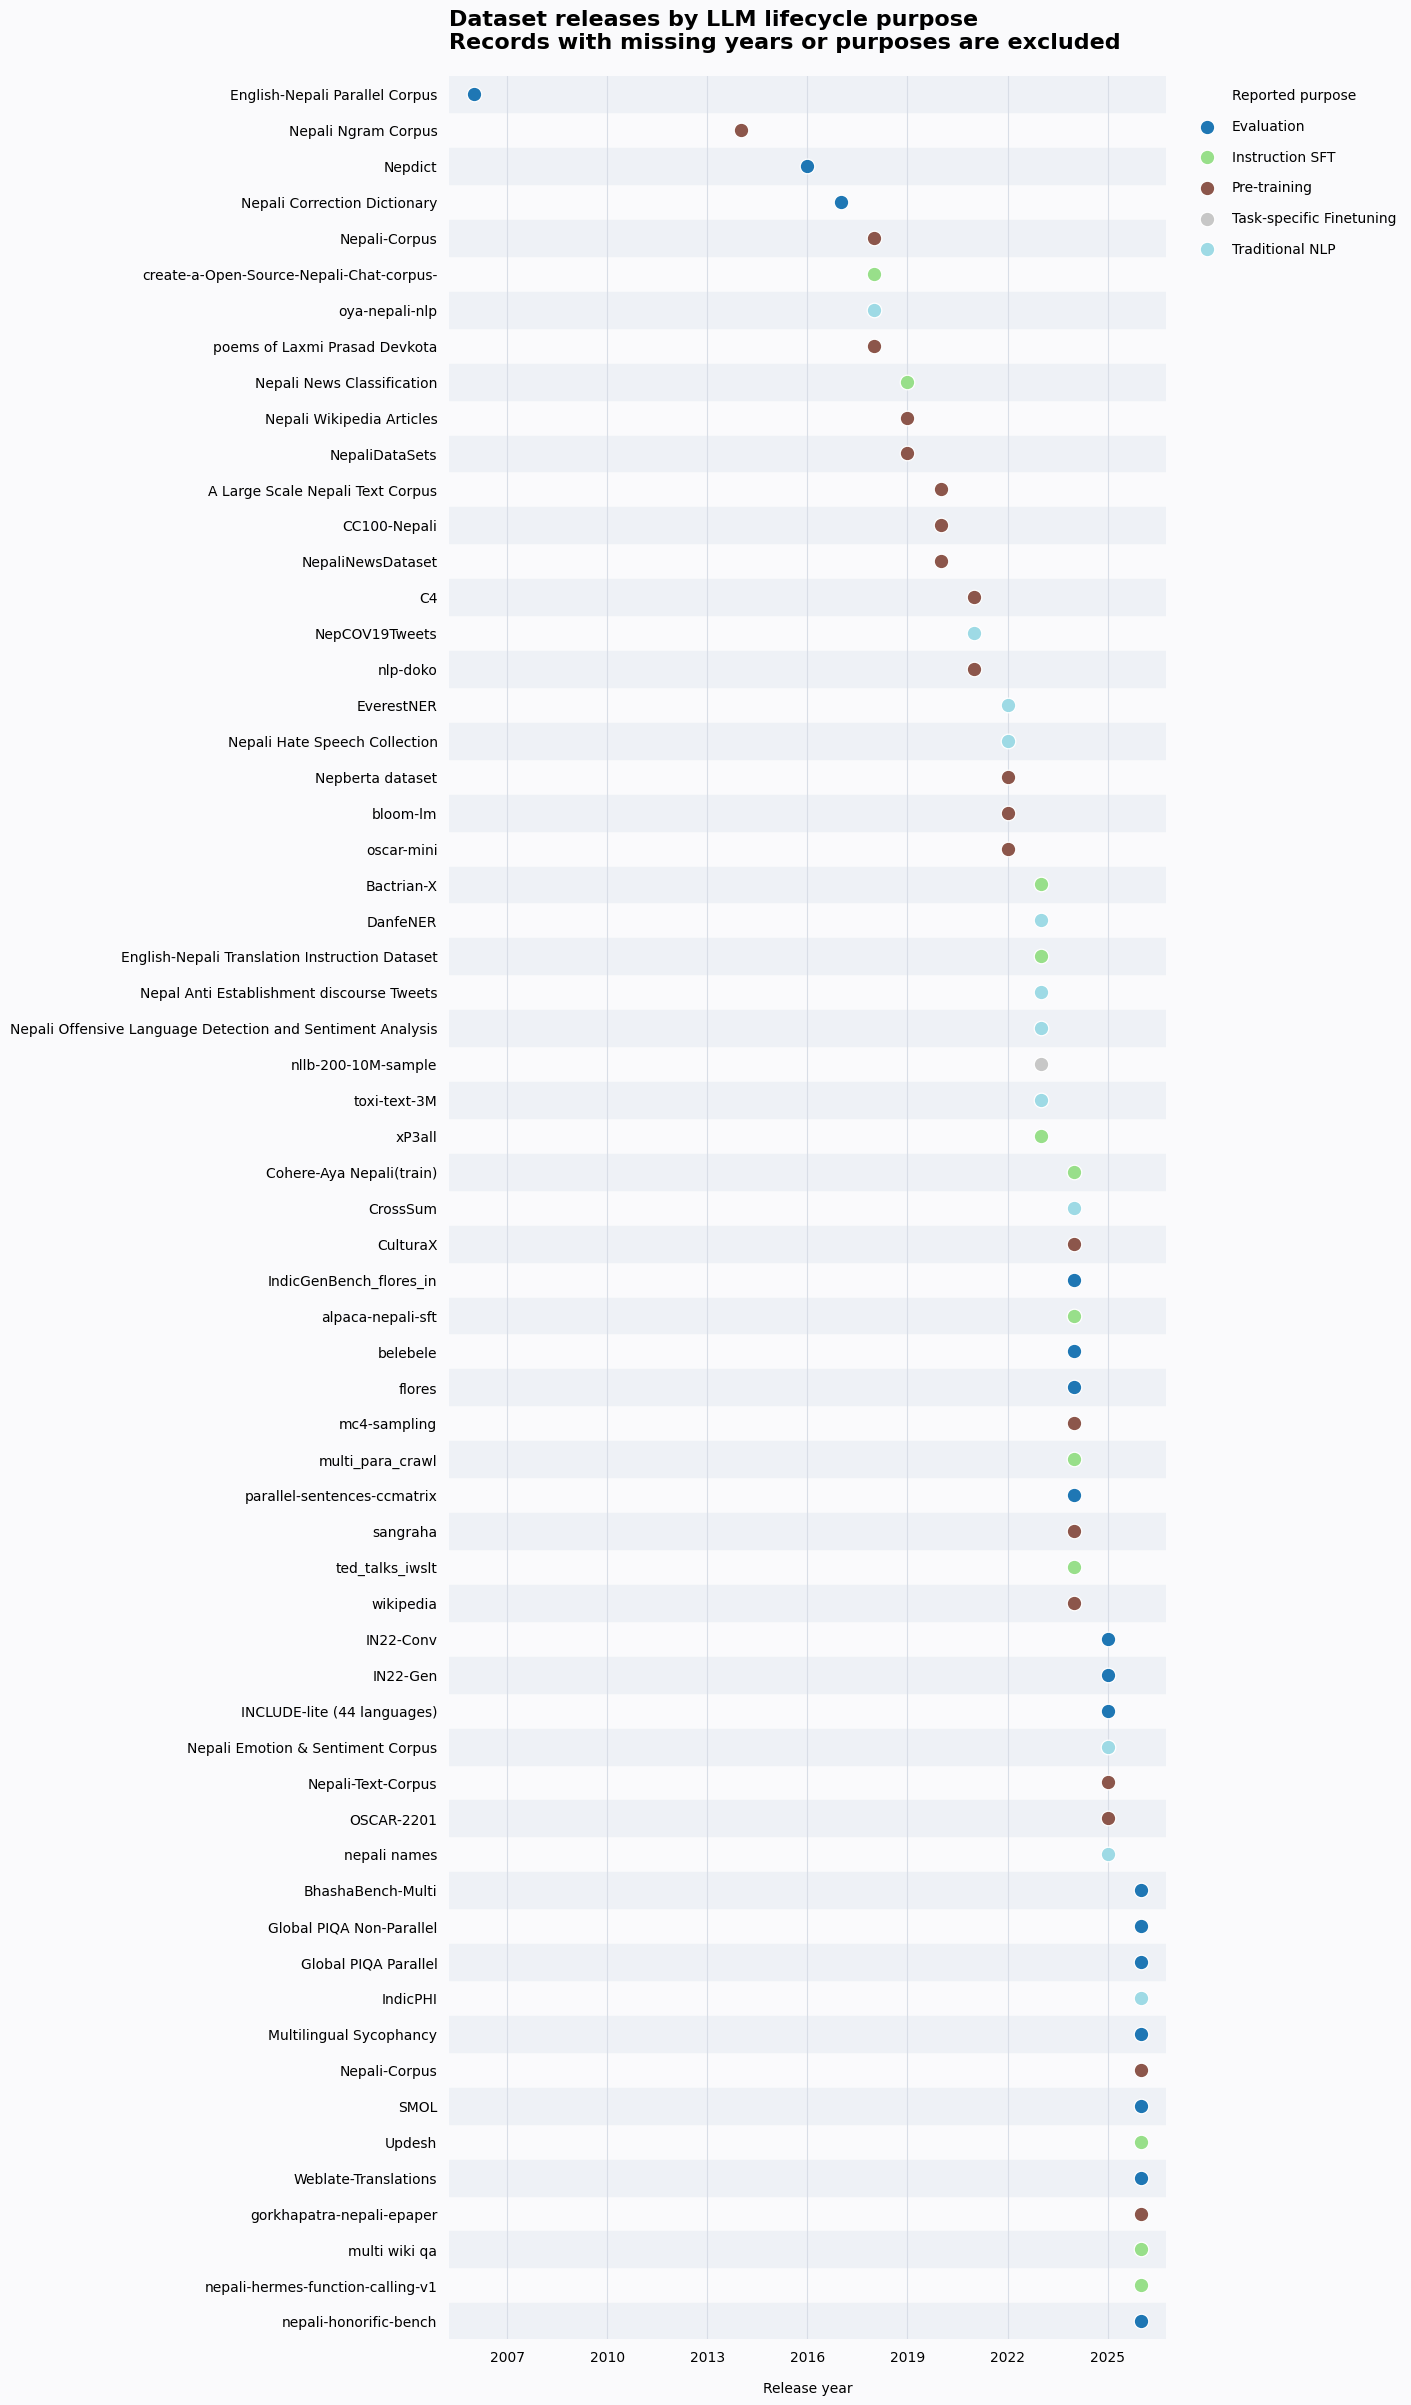

In [7]:
# Cell 2 — Dataset release timeline, colored by reported purpose.
if plot_df.empty:
    print("No records contain a dataset name, parseable year, and purpose.")
else:
    purposes = sorted(plot_df["Purpose"].unique())
    cmap = plt.get_cmap("tab20" if len(purposes) <= 20 else "turbo")
    colors = {
        purpose: cmap(i / max(len(purposes) - 1, 1))
        for i, purpose in enumerate(purposes)
    }

    with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 10}):
        fig, ax = plt.subplots(
            figsize=(14, max(5, len(plot_df) * 0.38)),
            constrained_layout=True,
        )
        fig.patch.set_facecolor("#FAFAFC")
        ax.set_facecolor("#FAFAFC")

        for i in range(0, len(plot_df), 2):
            ax.axhspan(i - 0.5, i + 0.5, color="#EEF1F6", zorder=0)

        for purpose in purposes:
            rows = plot_df[plot_df["Purpose"] == purpose]
            ax.scatter(
                rows["Year"], rows.index,
                s=110, color=colors[purpose],
                edgecolor="white", linewidth=0.9,
                label=fill(purpose, 34), zorder=3,
            )

        ax.set_yticks(plot_df.index)
        ax.set_yticklabels(plot_df["Dataset"])
        ax.set_ylim(len(plot_df) - 0.5, -0.5)
        ax.set_xlim(plot_df["Year"].min() - 0.75,
                    plot_df["Year"].max() + 0.75)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis="x", color="#D8DDE6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0, pad=8)
        ax.set_xlabel("Release year", labelpad=12)
        ax.set_title(
            "Dataset releases by LLM lifecycle purpose\n"
            "Records with missing years or purposes are excluded",
            loc="left", fontsize=16, fontweight="bold", pad=20,
        )

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.legend(
            title="Reported purpose", bbox_to_anchor=(1.02, 1),
            loc="upper left", frameon=False, labelspacing=1.2,
        )
        plt.show()

In [8]:
# Cell 1 — Prepare dataset names, release years, and purposes.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from textwrap import fill

data = df.rename(columns=lambda c: c.strip())
timeline = data[
    ["Dataset Name", "Year/Release Time", "Dataset Role (LLM Lifecycle)"]
].copy()
timeline.columns = ["Dataset", "Release", "Purpose"]

missing = {"", "na", "n/a", "nan", "none", "null", "unknown",
           "not available", "not specified", "-", "—", "?"}

for col in timeline:
    timeline[col] = timeline[col].astype("string").str.strip()
    timeline[col] = timeline[col].mask(
        timeline[col].str.lower().isin(missing)
    )

# Extract the first explicit year; exclude incomplete records.
timeline["Year"] = pd.to_numeric(
    timeline["Release"].str.extract(r"\b((?:19|20)\d{2})\b", expand=False),
    errors="coerce",
)
timeline = (
    timeline.dropna(subset=["Dataset", "Year", "Purpose"])
    .assign(Year=lambda d: d["Year"].astype(int))
    .drop_duplicates(["Dataset", "Year", "Purpose"])
    .sort_values(["Year", "Dataset"])
)

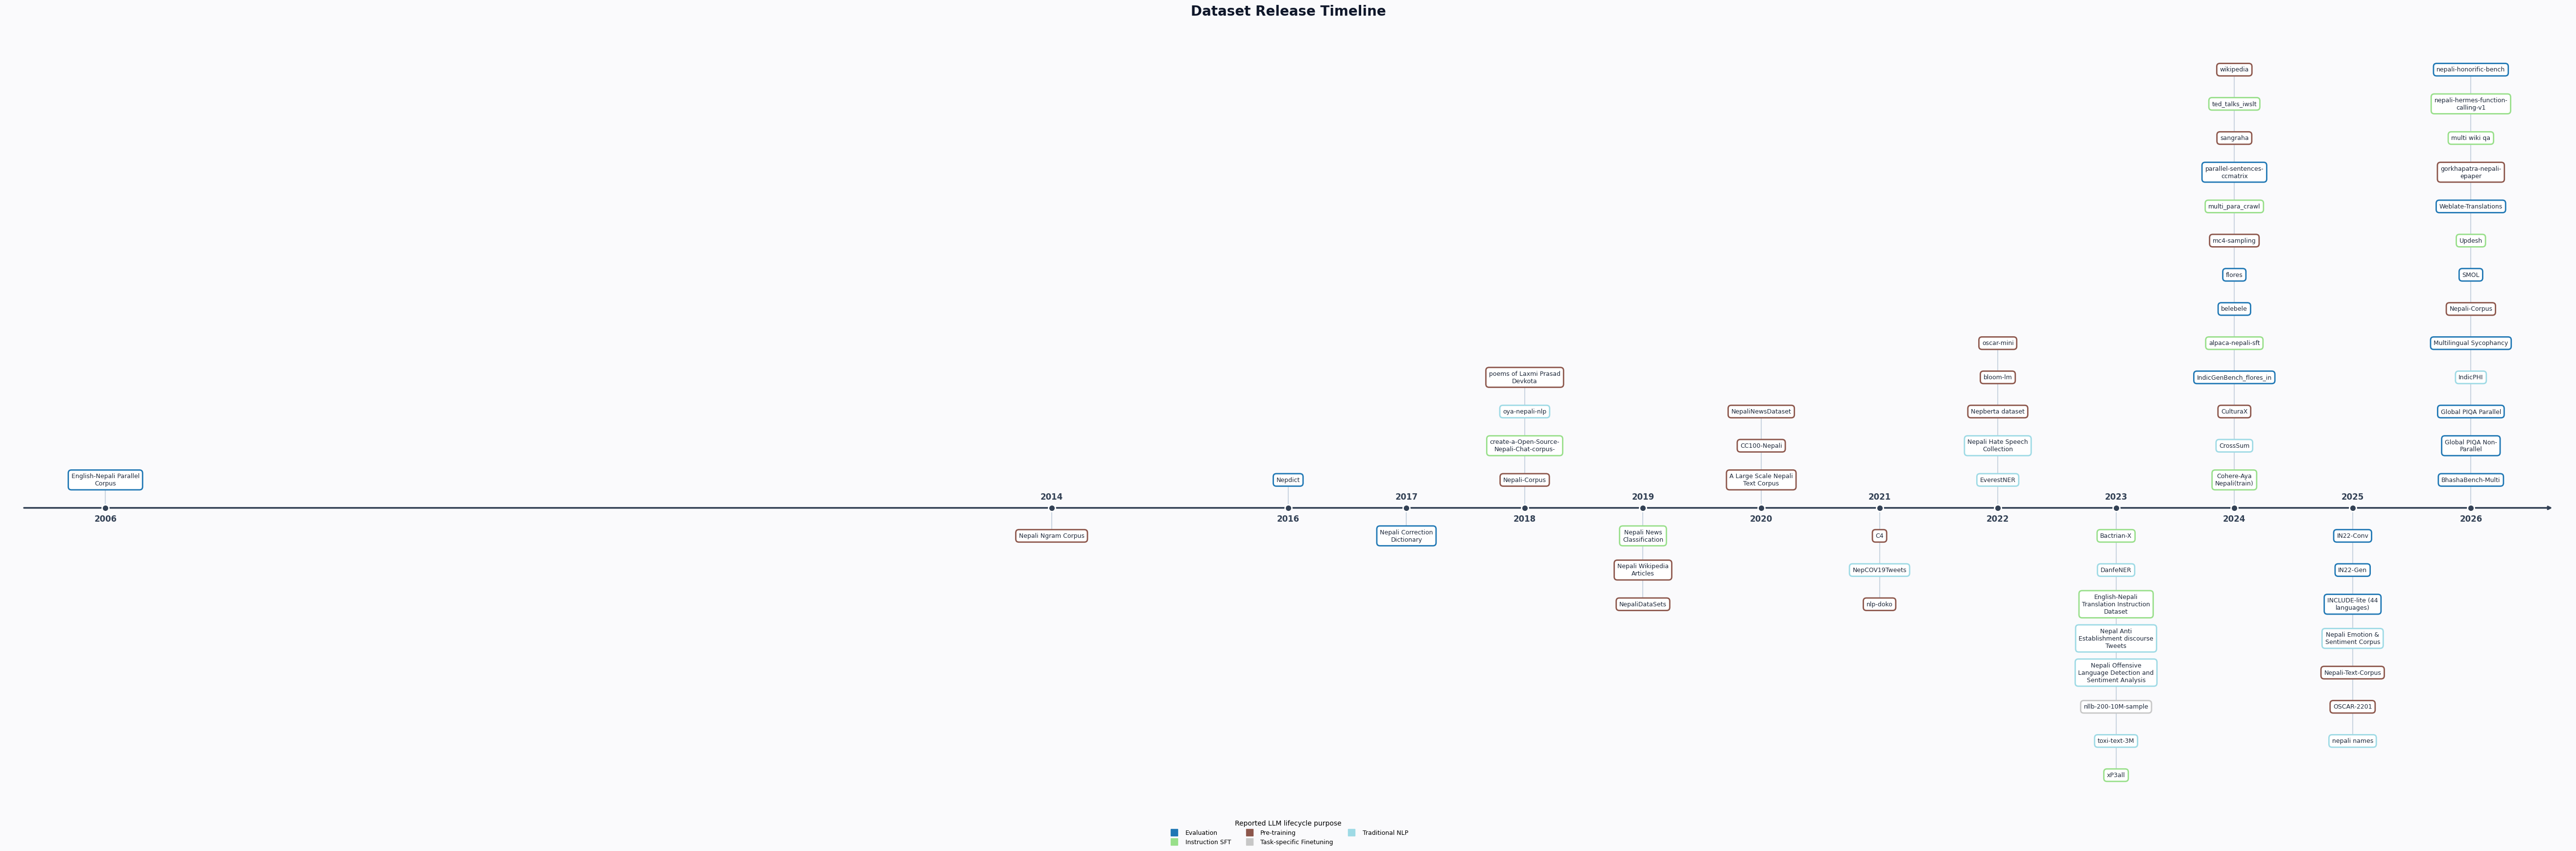

In [9]:
# Cell 2 — Horizontal timeline with dataset labels above and below.
if timeline.empty:
    print("No records with a dataset name, release year, and purpose.")
else:
    purposes = sorted(timeline["Purpose"].unique())
    cmap = plt.get_cmap("tab20" if len(purposes) <= 20 else "turbo")
    colors = {
        p: cmap(i / max(1, len(purposes) - 1))
        for i, p in enumerate(purposes)
    }

    years = sorted(timeline["Year"].unique())
    max_stack = int(timeline.groupby("Year").size().max())
    year_span = int(max(years) - min(years))

    fig, ax = plt.subplots(
        figsize=(max(14, 2.5 * (year_span + 1)),
                 max(7, 1.1 * max_stack + 3)),
        layout="constrained",
    )
    fig.patch.set_facecolor("#FAFAFC")
    ax.set_facecolor("#FAFAFC")

    # Central timeline arrow: horizontal spacing represents elapsed years.
    ax.annotate(
        "", xy=(max(years) + 0.7, 0), xytext=(min(years) - 0.7, 0),
        arrowprops=dict(arrowstyle="->", color="#334155", lw=2.5),
    )

    extents = [0]
    for i, year in enumerate(years):
        direction = 1 if i % 2 == 0 else -1
        rows = timeline[timeline["Year"] == year].reset_index(drop=True)
        end_y = direction * (0.9 + (len(rows) - 1) * 1.1)
        extents.append(end_y)

        ax.plot([year, year], [0, end_y], color="#CBD5E1", lw=1.5, zorder=1)
        ax.scatter(year, 0, s=100, color="#334155",
                   edgecolor="white", linewidth=2, zorder=4)
        ax.text(
            year, -direction * 0.35, str(year),
            ha="center", va="center", fontsize=12,
            fontweight="bold", color="#334155",
        )

        for j, row in rows.iterrows():
            y = direction * (0.9 + j * 1.1)
            color = colors[row["Purpose"]]
            ax.text(
                year, y, fill(row["Dataset"], width=23),
                ha="center", va="center", fontsize=9, color="#1E293B",
                bbox=dict(
                    boxstyle="round,pad=0.5",
                    facecolor="white", edgecolor=color, linewidth=2,
                ),
                zorder=3,
            )

    ax.set_xlim(min(years) - 0.85, max(years) + 0.85)
    ax.set_ylim(min(extents) - 1.2, max(extents) + 1.2)
    ax.set_title(
        "Dataset Release Timeline",
        fontsize=20, fontweight="bold", color="#0F172A", pad=25,
    )
    ax.axis("off")

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               markerfacecolor=colors[p], markeredgecolor=colors[p],
               markersize=10, label=fill(p, 35))
        for p in purposes
    ]
    fig.legend(
        handles=handles, title="Reported LLM lifecycle purpose",
        loc="outside lower center", ncol=min(3, len(purposes)),
        frameon=False, fontsize=9,
    )
    plt.show()

In [10]:
ax.set_title("Dataset Release Timeline by LLM Lifecycle Purpose",
             fontsize=20, fontweight="bold", pad=25)

fig.savefig("dataset_release_timeline.png",
            dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

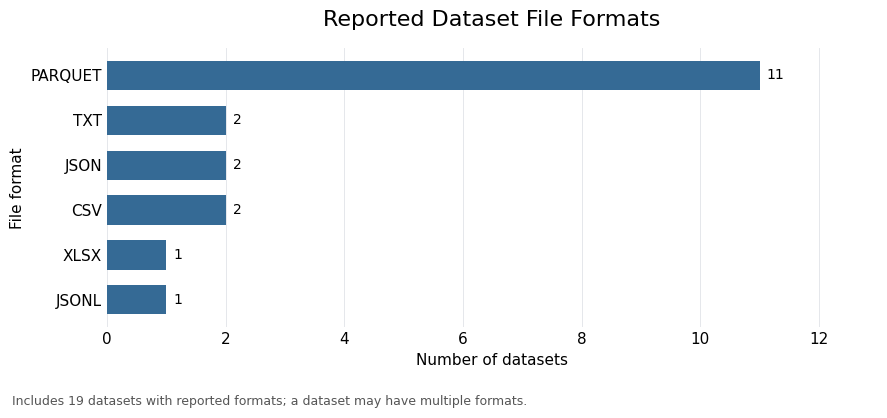

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Count each dataset once per reported format; exclude missing values.
d = df.rename(columns=lambda c: c.strip())
formats = d[["Dataset Name", "Extension format"]].dropna().copy()
formats["Format"] = (
    formats["Extension format"].astype(str).str.lower()
    .str.split(r"[,;/|\n]+")
)
formats = formats.explode("Format")
formats["Format"] = formats["Format"].str.strip(" .").str.upper()
formats = formats[
    ~formats["Format"].isin(["", "N/A", "NA", "N", "A", "NAN", "NONE",
                              "UNKNOWN", "NOT SPECIFIED", "-", "—"])
].drop_duplicates(["Dataset Name", "Format"])

counts = formats.groupby("Format")["Dataset Name"].nunique().sort_values()

if counts.empty:
    print("No reported file formats available to plot.")
else:
    with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 11}):
        fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(counts) + 1.5)))
        bars = ax.barh(counts.index, counts.values, color="#356A95", height=0.65)
        ax.bar_label(bars, padding=5, fontsize=10)

        ax.set_title("Reported Dataset File Formats", fontsize=16, pad=16)
        ax.set_xlabel("Number of datasets")
        ax.set_ylabel("File format")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xlim(0, counts.max() * 1.18)
        ax.grid(axis="x", color="#E5E7EB", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        n = formats["Dataset Name"].nunique()
        fig.text(0.02, 0.02,
                 f"Includes {n} datasets with reported formats; a dataset may have multiple formats.",
                 fontsize=9, color="#555555")
        fig.tight_layout(rect=(0, 0.07, 1, 1))

        fig.savefig("dataset_file_formats.png", dpi=300,
                    bbox_inches="tight", facecolor="white")
        fig.savefig("dataset_file_formats.pdf",
                    bbox_inches="tight", facecolor="white")
        plt.show()

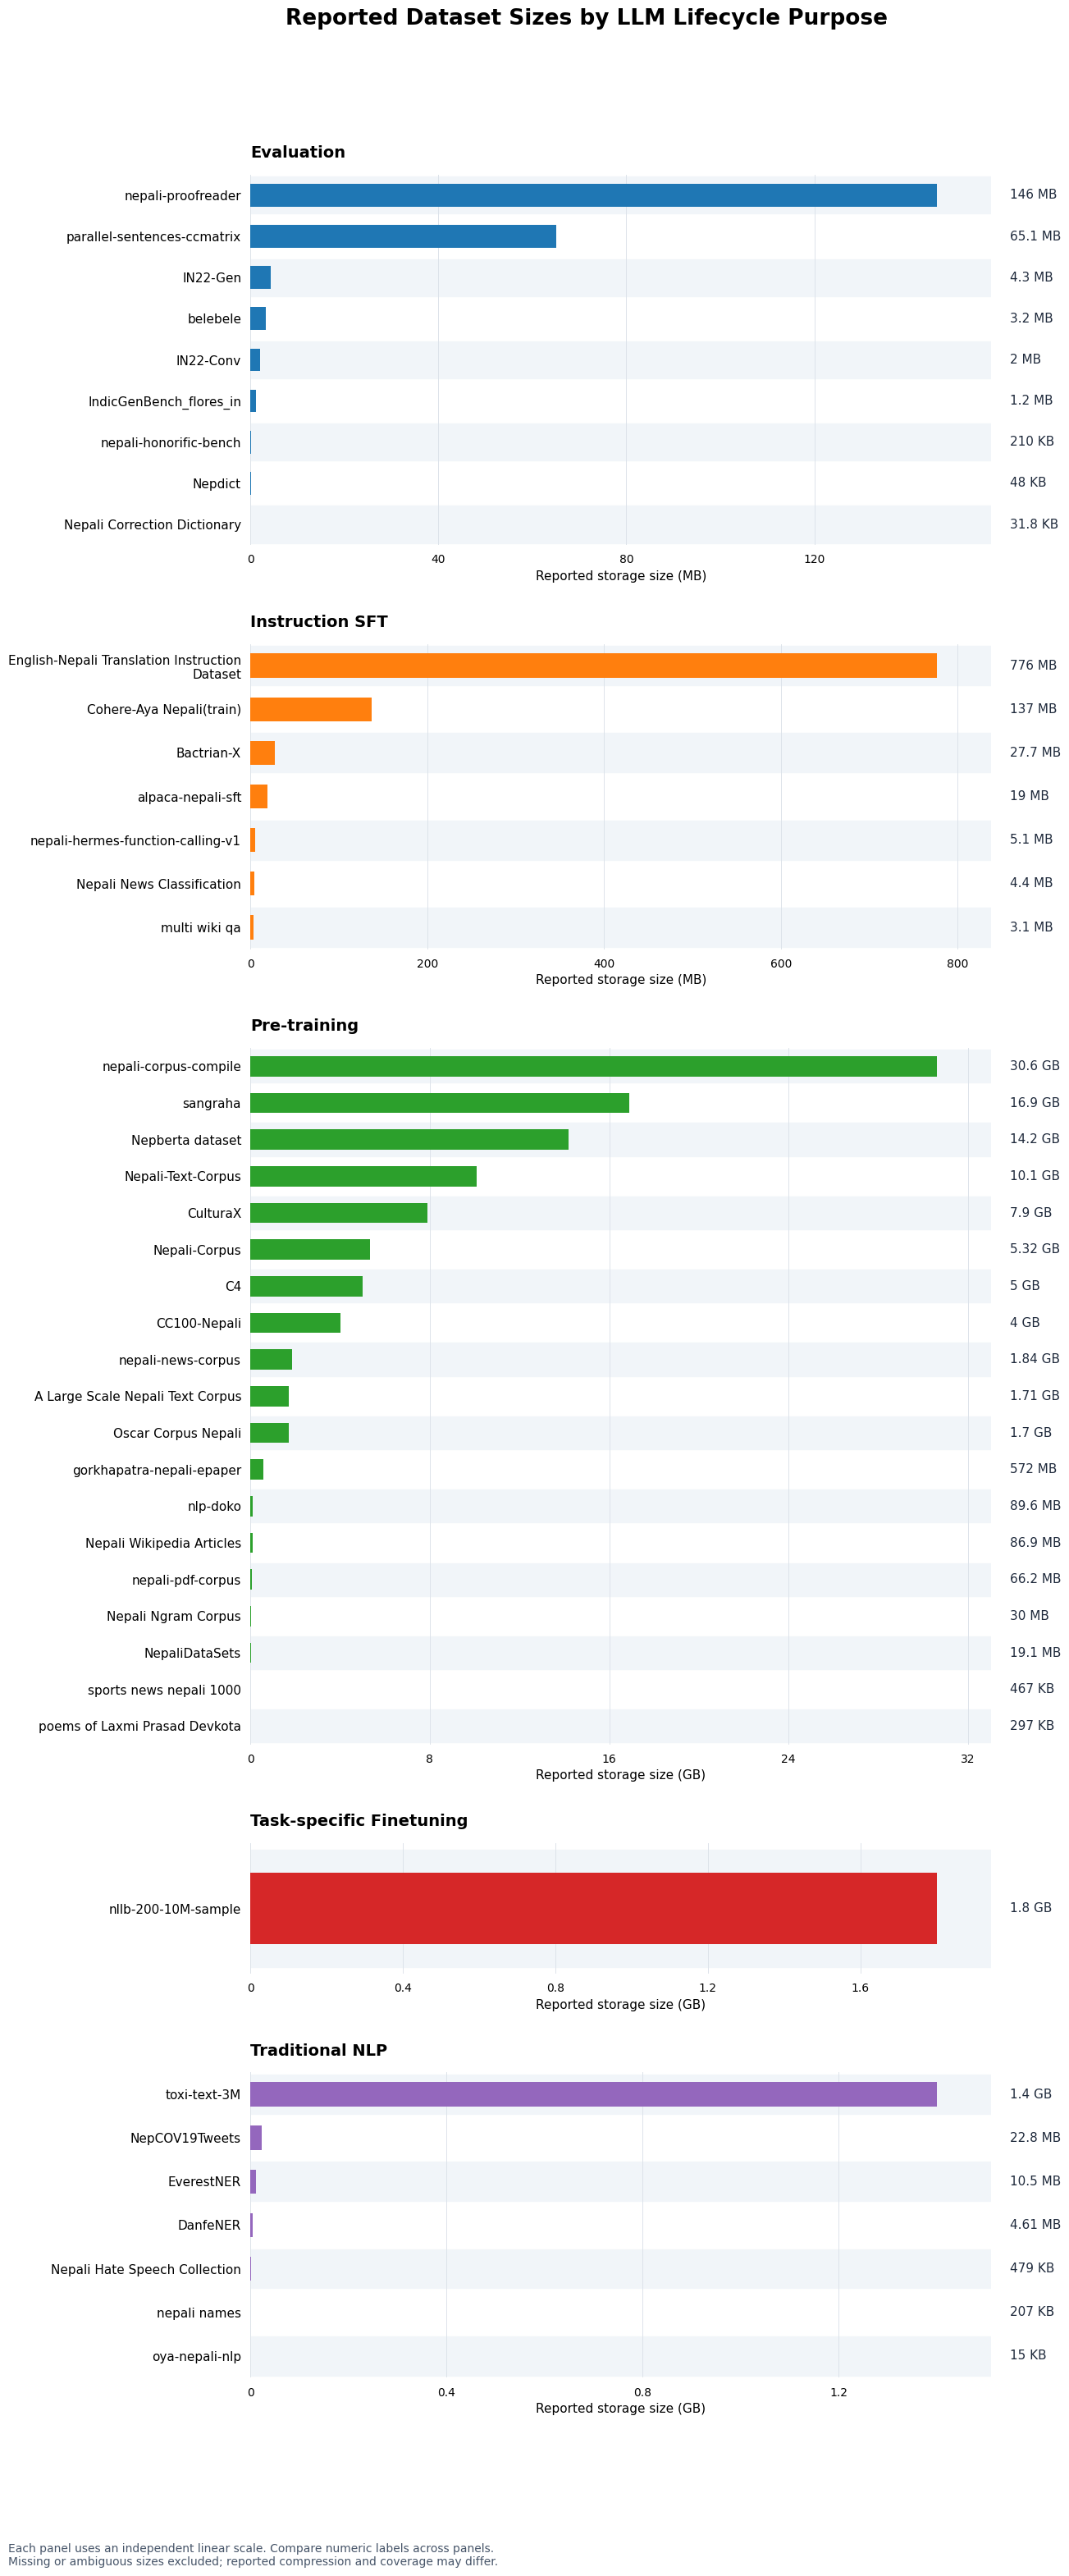

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
from textwrap import fill

if sizes.empty:
    print("No valid dataset sizes available.")
else:
    groups = list(sizes.groupby("Purpose", sort=True))
    heights = [max(2.2, len(group) * 0.55 + 1.3) for _, group in groups]

    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(15, sum(heights) + 1.2),
        gridspec_kw={"height_ratios": heights},
        squeeze=False
    )
    palette = plt.get_cmap("tab10")

    for i, (purpose, group) in enumerate(groups):
        ax = axes[i, 0]
        group = group.sort_values("Bytes", ascending=False)
        y = np.arange(len(group))
        largest = group["Bytes"].max()

        # Choose a readable unit for each purpose panel.
        if largest >= 1e9:
            divisor, unit = 1e9, "GB"
        elif largest >= 1e6:
            divisor, unit = 1e6, "MB"
        elif largest >= 1e3:
            divisor, unit = 1e3, "KB"
        else:
            divisor, unit = 1, "B"

        values = group["Bytes"] / divisor

        # Subtle row bands help match names, bars, and size labels.
        for j in range(0, len(group), 2):
            ax.axhspan(j - 0.45, j + 0.45, color="#F1F5F9", zorder=0)

        ax.barh(y, values, height=0.55, color=palette(i % 10), zorder=3)

        # Fixed right-hand column keeps small dataset sizes readable.
        for j, byte_count in enumerate(group["Bytes"]):
            ax.text(
                1.025, j, size_label(byte_count),
                transform=ax.get_yaxis_transform(),
                ha="left", va="center", fontsize=11,
                fontweight="medium", color="#1E293B", clip_on=False
            )

        ax.set_yticks(y)
        ax.set_yticklabels(
            [fill(str(name), 38) for name in group["Dataset"]],
            fontsize=11
        )
        ax.set_ylim(len(group) - 0.5, -0.5)
        ax.set_xlim(0, values.max() * 1.08)
        ax.set_title(fill(str(purpose), 75), loc="left",
                     fontsize=14, fontweight="bold", pad=15)
        ax.set_xlabel(f"Reported storage size ({unit})", fontsize=11)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.3g}"))
        ax.grid(axis="x", color="#DDE3EA", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0, pad=8)

        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(
        "Reported Dataset Sizes by LLM Lifecycle Purpose",
        fontsize=19, fontweight="bold", y=0.995
    )
    fig.text(
        0.03, 0.012,
        "Each panel uses an independent linear scale. Compare numeric labels across panels.\n"
        "Missing or ambiguous sizes excluded; reported compression and coverage may differ.",
        fontsize=10, color="#475569"
    )
    fig.tight_layout(rect=(0.02, 0.065, 0.90, 0.96), h_pad=2.8)

    fig.savefig("dataset_sizes_by_purpose_clear.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig("dataset_sizes_by_purpose_clear.pdf",
                bbox_inches="tight", facecolor="white")
    plt.show()

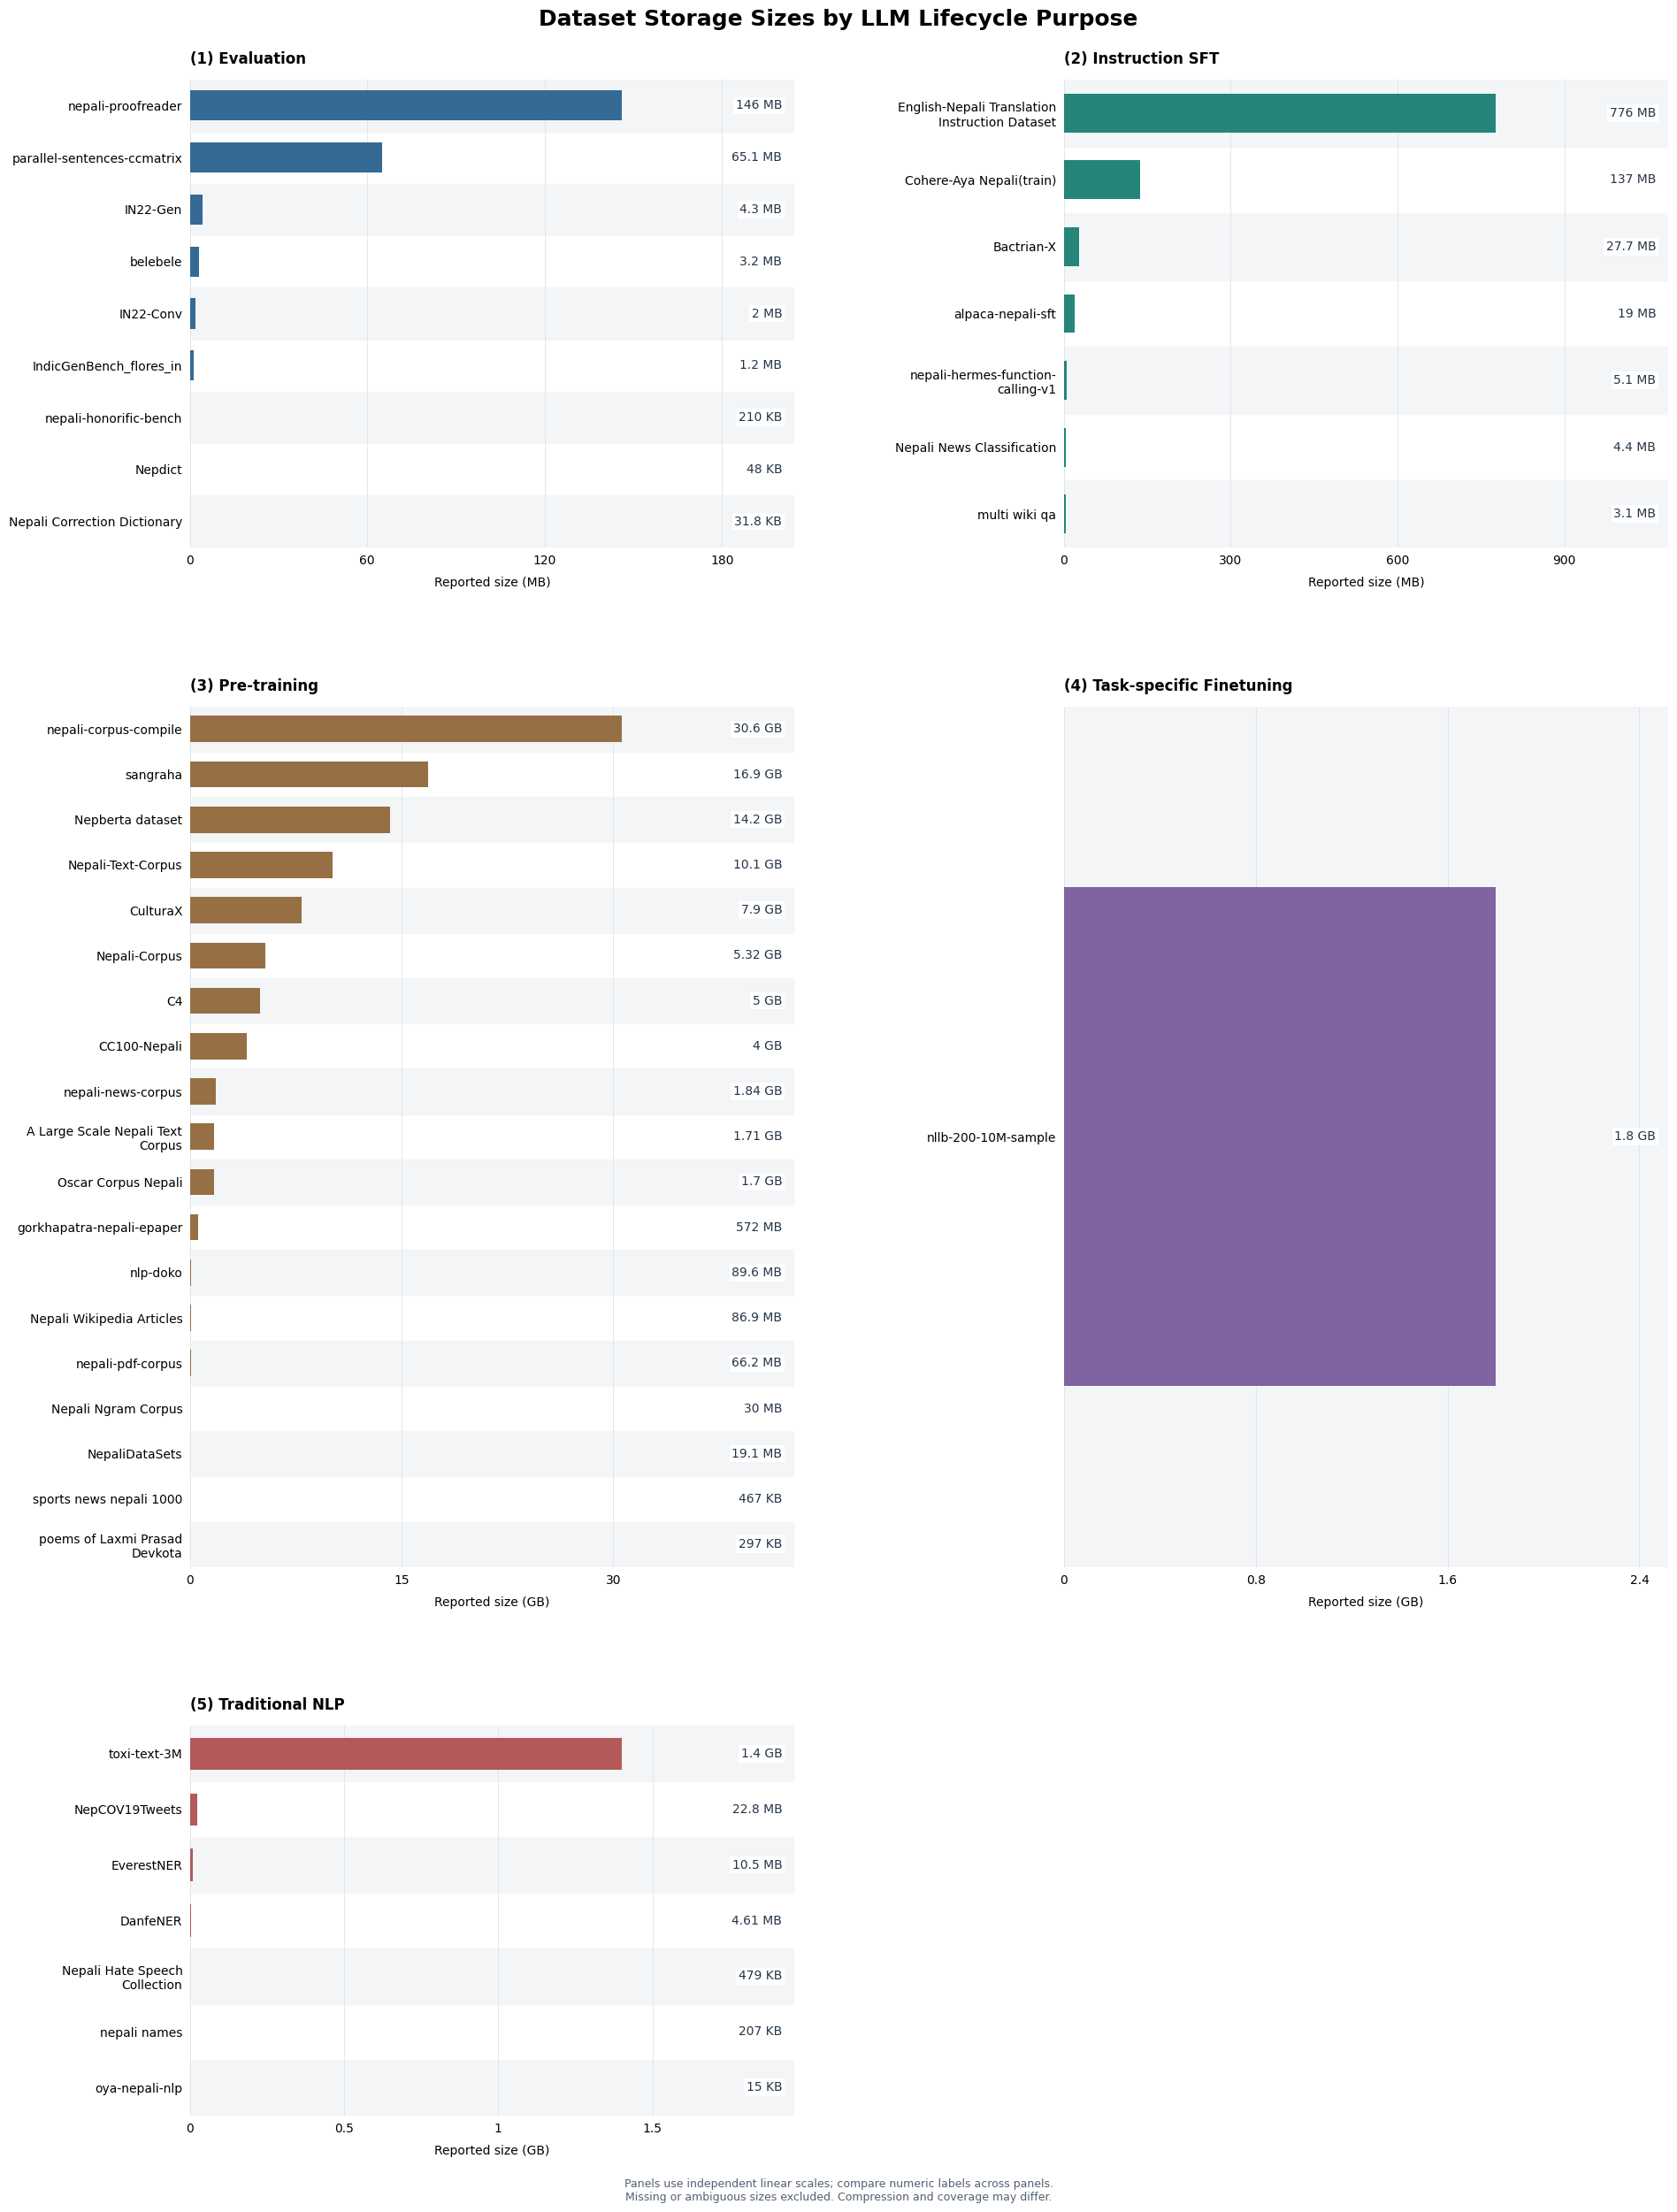

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
from textwrap import fill

if sizes.empty:
    print("No valid dataset sizes available.")
else:
    groups = list(sizes.groupby("Purpose", sort=True))
    ncols = min(2, len(groups))
    nrows = math.ceil(len(groups) / ncols)

    # Allocate enough vertical space for dataset labels in each row.
    row_heights = [
        max(3.2, 0.55 * max(len(g) for _, g in groups[r*ncols:(r+1)*ncols]) + 1.6)
        for r in range(nrows)
    ]

    with plt.rc_context({
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titleweight": "bold",
        "pdf.fonttype": 42
    }):
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(19 if ncols == 2 else 11, sum(row_heights) + 1),
            gridspec_kw={"height_ratios": row_heights},
            layout="constrained",
            squeeze=False
        )
        fig.set_constrained_layout_pads(w_pad=0.12, h_pad=0.12,
                                        wspace=0.12, hspace=0.12)
        palette = ["#356A95", "#258579", "#967044", "#8064A2",
                   "#B45959", "#577C46"]

        for i, (purpose, group) in enumerate(groups):
            ax = axes.flat[i]
            group = group.sort_values("Bytes", ascending=False)
            y = np.arange(len(group))
            largest = group["Bytes"].max()

            divisor, unit = next(
                (factor, label)
                for factor, label in [
                    (1e12, "TB"), (1e9, "GB"), (1e6, "MB"),
                    (1e3, "KB"), (1, "B")
                ]
                if largest >= factor or factor == 1
            )
            values = group["Bytes"] / divisor

            for j in range(0, len(group), 2):
                ax.axhspan(j - 0.5, j + 0.5, color="#F3F5F7", zorder=0)

            ax.barh(y, values, height=0.58,
                    color=palette[i % len(palette)], zorder=3)

            # Aligned numeric column: even tiny datasets remain readable.
            for j, byte_count in enumerate(group["Bytes"]):
                ax.text(
                    0.98, j, size_label(byte_count),
                    transform=ax.get_yaxis_transform(),
                    ha="right", va="center",
                    fontsize=10, color="#243447",
                    bbox=dict(facecolor="white", edgecolor="none", pad=2)
                )

            ax.set_yticks(y)
            ax.set_yticklabels(
                [fill(str(name), 28) for name in group["Dataset"]]
            )
            ax.set_ylim(len(group) - 0.5, -0.5)
            ax.set_xlim(0, values.max() * 1.40)
            ax.set_title(
                f"({i + 1}) {fill(str(purpose), 42)}",
                loc="left", fontsize=12, pad=13
            )
            ax.set_xlabel(f"Reported size ({unit})", labelpad=8)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.3g}"))
            ax.grid(axis="x", color="#DDE3E9", linewidth=0.6)
            ax.set_axisbelow(True)
            ax.tick_params(axis="both", length=0, pad=6)

            for spine in ax.spines.values():
                spine.set_visible(False)

        for ax in list(axes.flat)[len(groups):]:
            ax.set_visible(False)

        fig.suptitle(
            "Dataset Storage Sizes by LLM Lifecycle Purpose",
            fontsize=18, fontweight="bold"
        )
        fig.supxlabel(
            "Panels use independent linear scales; compare numeric labels across panels.\n"
            "Missing or ambiguous sizes excluded. Compression and coverage may differ.",
            fontsize=9, color="#526070"
        )

        fig.savefig("dataset_size_subplots.png", dpi=300,
                    bbox_inches="tight", facecolor="white")
        fig.savefig("dataset_size_subplots.pdf",
                    bbox_inches="tight", facecolor="white")
        plt.show()

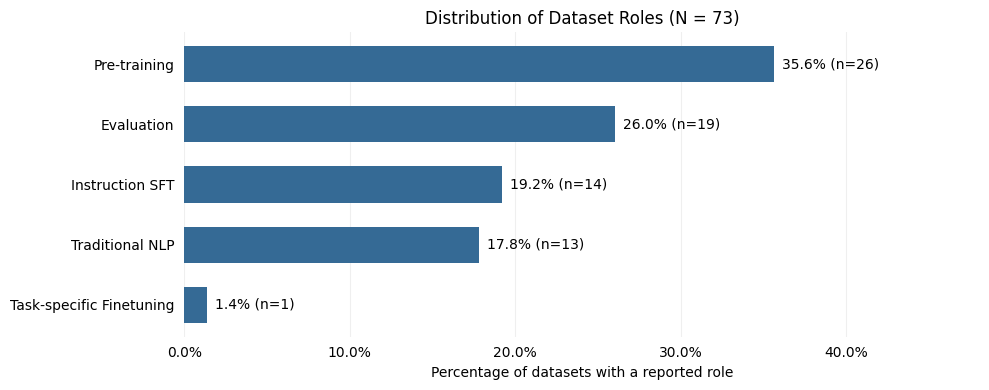

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from textwrap import fill

roles = df.rename(columns=str.strip)["Dataset Role (LLM Lifecycle)"]
roles = roles.astype("string").str.strip()
roles = roles[roles.notna() & ~roles.str.lower().isin(
    ["", "na", "n/a", "none", "nan", "unknown", "not specified", "-", "—"]
)]
counts = roles.value_counts().sort_values()
percent = counts / counts.sum() * 100

if counts.empty:
    print("No reported dataset roles found.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(counts) * 0.65)))
    bars = ax.barh([fill(x, 40) for x in counts.index], percent,
                   color="#356A95", height=0.6)
    ax.bar_label(bars, labels=[
        f"{p:.1f}% (n={n})" for p, n in zip(percent, counts)
    ], padding=6, fontsize=10)

    ax.set(title=f"Distribution of Dataset Roles (N = {counts.sum()})",
           xlabel="Percentage of datasets with a reported role",
           xlim=(0, percent.max() * 1.35))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    fig.savefig("dataset_role_distribution.png", dpi=300, bbox_inches="tight")
    fig.savefig("dataset_role_distribution.pdf", bbox_inches="tight")
    plt.show()

In [16]:
# Cell 1 — Parse multiple entries and normalize common names/codes.
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from textwrap import fill

d = df.rename(columns=lambda c: c.strip()).reset_index(drop=True)
missing = {"", "na", "n/a", "nan", "none", "null", "unknown",
           "not specified", "not reported", "not available", "-", "—"}

language_aliases = {
    "en": "English", "eng": "English", "english": "English",
    "ne": "Nepali", "nep": "Nepali", "nepali": "Nepali", "nepali language": "Nepali",
    "hi": "Hindi", "hin": "Hindi", "hindi": "Hindi",
    "sa": "Sanskrit", "san": "Sanskrit", "sanskrit": "Sanskrit",
    "mai": "Maithili", "maithili": "Maithili",
    "bho": "Bhojpuri", "bhojpuri": "Bhojpuri",
    "new": "Nepal Bhasa", "newari": "Nepal Bhasa", "nepal bhasa": "Nepal Bhasa",
    "bn": "Bengali", "ben": "Bengali", "bengali": "Bengali",
    "ur": "Urdu", "urd": "Urdu", "urdu": "Urdu",
}
script_aliases = {
    "deva": "Devanagari", "devanagari": "Devanagari",
    "devnagari": "Devanagari", "devanagari script": "Devanagari",
    "latn": "Latin", "latin": "Latin", "roman": "Latin",
    "latin script": "Latin", "roman script": "Latin",
    "arab": "Arabic", "arabic": "Arabic",
    "beng": "Bengali", "bengali": "Bengali",
    "tibt": "Tibetan", "tibetan": "Tibetan",
}

def parse_column(column, aliases):
    records = []
    for idx, value in d[column].items():
        if pd.isna(value):
            continue
        text = re.sub(r"\s+", " ", str(value)).strip()
        if text.casefold() in missing:
            continue

        # Split explicit lists, protecting delimiters inside parentheses.
        parts = re.split(
            r"(?:[,;/|+&]|\band\b)(?![^()]*\))",
            str(value), flags=re.I
        )
        for part in parts:
            raw = re.sub(r"\s+", " ", part).strip(" \t\n•")
            if raw.casefold() in missing:
                continue
            key = raw.casefold()

            # Normalize "English (en)" only when both identify the same label.
            match = re.fullmatch(r"(.+?)\s*\(([^()]*)\)", key)
            if match:
                base, code = [x.strip() for x in match.groups()]
                if base in aliases and aliases.get(code) == aliases[base]:
                    key = base

            label = aliases.get(key, raw)
            records.append((idx, raw, label, key in aliases))

    return pd.DataFrame(records, columns=["Row", "Original", "Label", "Recognized"])

languages = parse_column("Language Coverage", language_aliases)
scripts = parse_column("Script", script_aliases)

# Review unfamiliar labels before using the figure in a paper.
review = pd.concat([
    languages.assign(Column="Language Coverage"),
    scripts.assign(Column="Script")
])
review = review.loc[~review["Recognized"],
                    ["Column", "Original", "Label"]].drop_duplicates()
if not review.empty:
    print("Review these preserved labels; add aliases above if needed:")
    display(review)

Review these preserved labels; add aliases above if needed:


,Column,Original,Label
0,Language Coverage,Nepali-only,Nepali-only
1,Language Coverage,Multilingual,Multilingual
3,Language Coverage,Bilingual (Nepali-English),Bilingual (Nepali-English)
18,Language Coverage,Other,Other
1,Script,Mixed (Devanagari + romanized),Mixed (Devanagari + romanized)
2,Script,Mixed(Nepali+English),Mixed(Nepali+English)
12,Script,Romanized,Romanized
17,Script,Other,Other


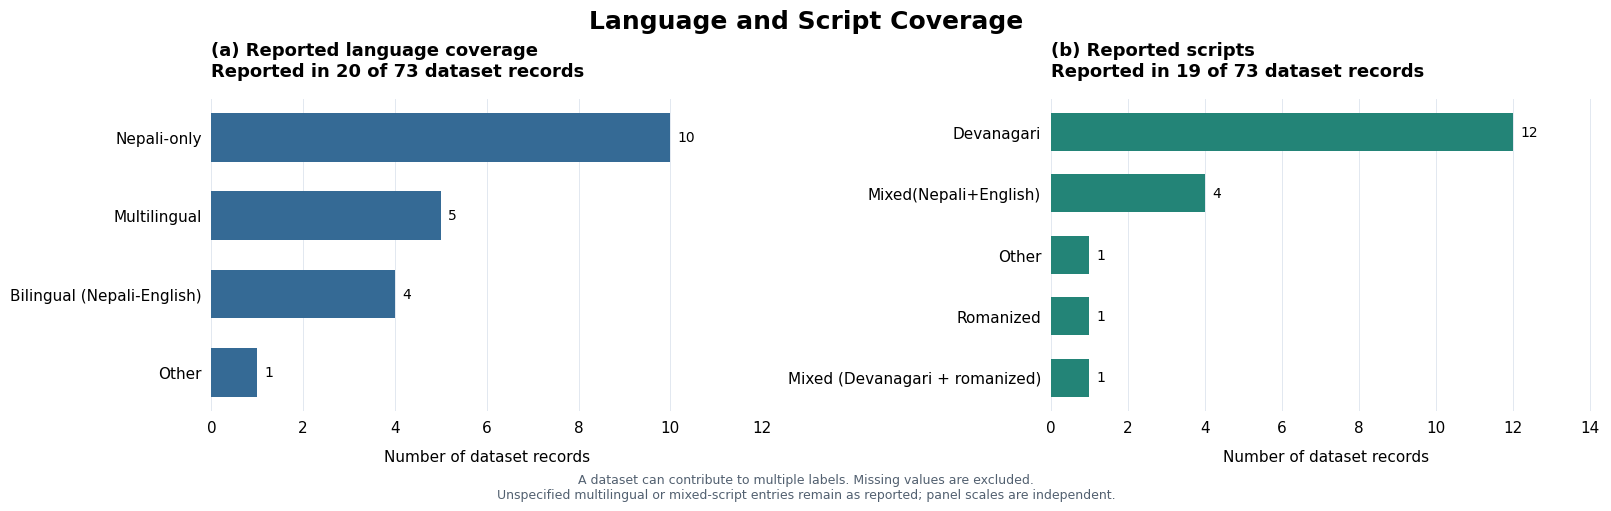

In [17]:
# Cell 2 — Professional subplot figure; save high-resolution PNG and vector PDF.
panels = [
    (languages, "(a) Reported language coverage", "#356A95"),
    (scripts, "(b) Reported scripts", "#238477")
]
max_labels = max(1, languages["Label"].nunique(), scripts["Label"].nunique())

with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 11,
                     "pdf.fonttype": 42}):
    fig, axes = plt.subplots(
        1, 2, figsize=(16, max(5, max_labels * 0.48 + 2)),
        layout="constrained"
    )

    for ax, (table, title, color) in zip(axes, panels):
        counts = (
            table.drop_duplicates(["Row", "Label"])["Label"]
            .value_counts().sort_values()
        )
        n_reported = table["Row"].nunique()

        ax.set_title(
            f"{title}\nReported in {n_reported} of {len(d)} dataset records",
            loc="left", fontsize=13, fontweight="bold", pad=16
        )
        if counts.empty:
            ax.text(0.5, 0.5, "No reported values",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        bars = ax.barh(range(len(counts)), counts.values,
                       color=color, height=0.62)
        ax.set_yticks(range(len(counts)))
        ax.set_yticklabels([fill(str(label), 30) for label in counts.index])
        ax.bar_label(bars, padding=5, fontsize=10)
        ax.set_xlim(0, counts.max() * 1.15 + 0.5)
        ax.set_xlabel("Number of dataset records", labelpad=10)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis="x", color="#E2E8F0", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.tick_params(length=0, pad=7)
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle("Language and Script Coverage",
                 fontsize=18, fontweight="bold")
    fig.supxlabel(
        "A dataset can contribute to multiple labels. Missing values are excluded.\n"
        "Unspecified multilingual or mixed-script entries remain as reported; panel scales are independent.",
        fontsize=9, color="#526070"
    )
    fig.savefig("language_script_coverage.png", dpi=300,
                bbox_inches="tight", facecolor="white")
    fig.savefig("language_script_coverage.pdf",
                bbox_inches="tight", facecolor="white")
    plt.show()

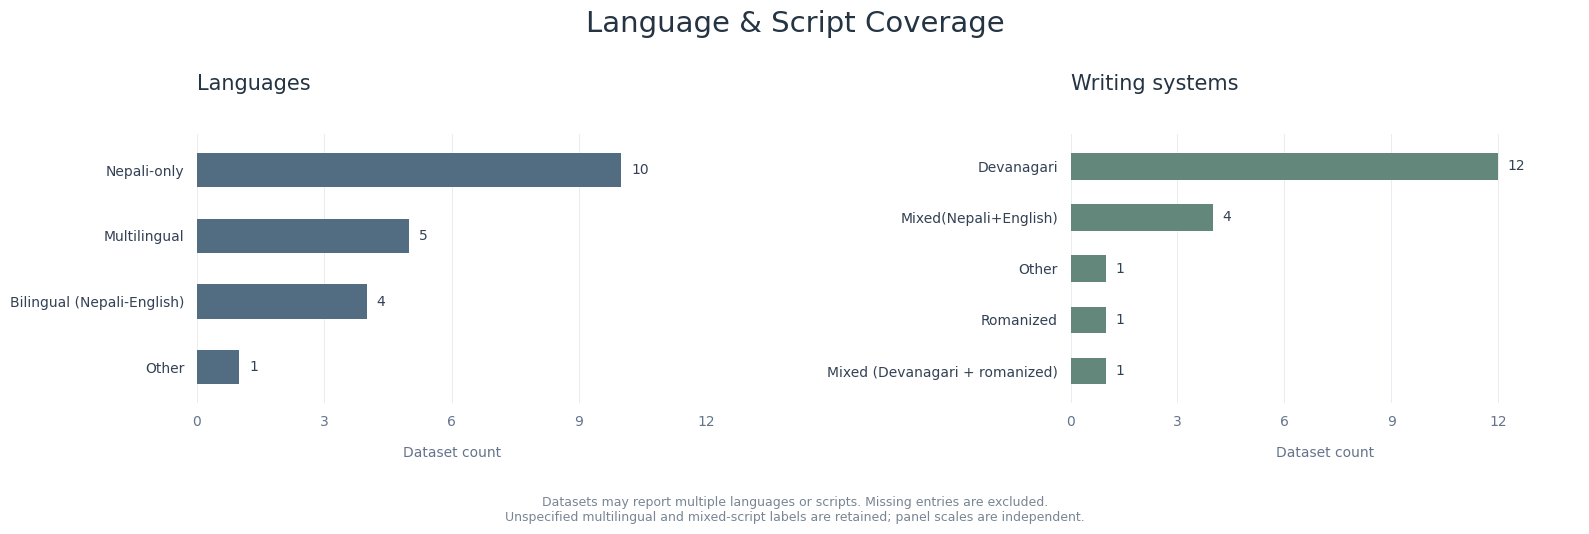

In [19]:
import numpy as np

panels = [
    (languages, "Languages", "#526D82"),
    (scripts, "Writing systems", "#64877B")
]
max_labels = max(1, languages["Label"].nunique(), scripts["Label"].nunique())

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "text.color": "#253443",
    "axes.labelcolor": "#64748B",
    "xtick.color": "#64748B",
    "ytick.color": "#334155",
    "pdf.fonttype": 42
}):
    fig, axes = plt.subplots(
        1, 2, figsize=(16, max(5.5, max_labels * 0.48 + 2.2)),
        layout="constrained"
    )
    fig.set_constrained_layout_pads(
        w_pad=0.15, h_pad=0.18, wspace=0.14
    )

    for ax, (table, title, color) in zip(axes, panels):
        counts = (
            table.drop_duplicates(["Row", "Label"])["Label"]
            .value_counts().sort_values()
        )
        n_reported = table["Row"].nunique()

        ax.set_title(title, loc="left", fontsize=15,
                     fontweight="medium", pad=32)
        # ax.text(
        #     0, 1.025, f"{n_reported} of {len(d)} datasets with reported information",
        #     transform=ax.transAxes, fontsize=9, color="#788594"
        # )

        if counts.empty:
            ax.text(0.5, 0.5, "No reported values",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        y = np.arange(len(counts))
        bars = ax.barh(y, counts.values, height=0.52, color=color)
        ax.set_yticks(y)
        ax.set_yticklabels([fill(str(label), 30) for label in counts.index])
        ax.bar_label(bars, padding=7, fontsize=10, color="#334155")

        ax.set_xlim(0, counts.max() * 1.15 + 0.5)
        ax.margins(y=0.08)
        ax.set_xlabel("Dataset count", labelpad=12, fontsize=10)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.grid(axis="x", color="#E9EDF2", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0, pad=9)

        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(
        "Language & Script Coverage",
        fontsize=21, fontweight="medium", color="#253443"
    )
    fig.supxlabel(
        "Datasets may report multiple languages or scripts. Missing entries are excluded.\n"
        "Unspecified multilingual and mixed-script labels are retained; panel scales are independent.",
        fontsize=9, color="#788594"
    )

    fig.savefig("language_script_coverage.png", dpi=300,
                bbox_inches="tight", facecolor="white")
    fig.savefig("language_script_coverage.pdf",
                bbox_inches="tight", facecolor="white")
    plt.show()

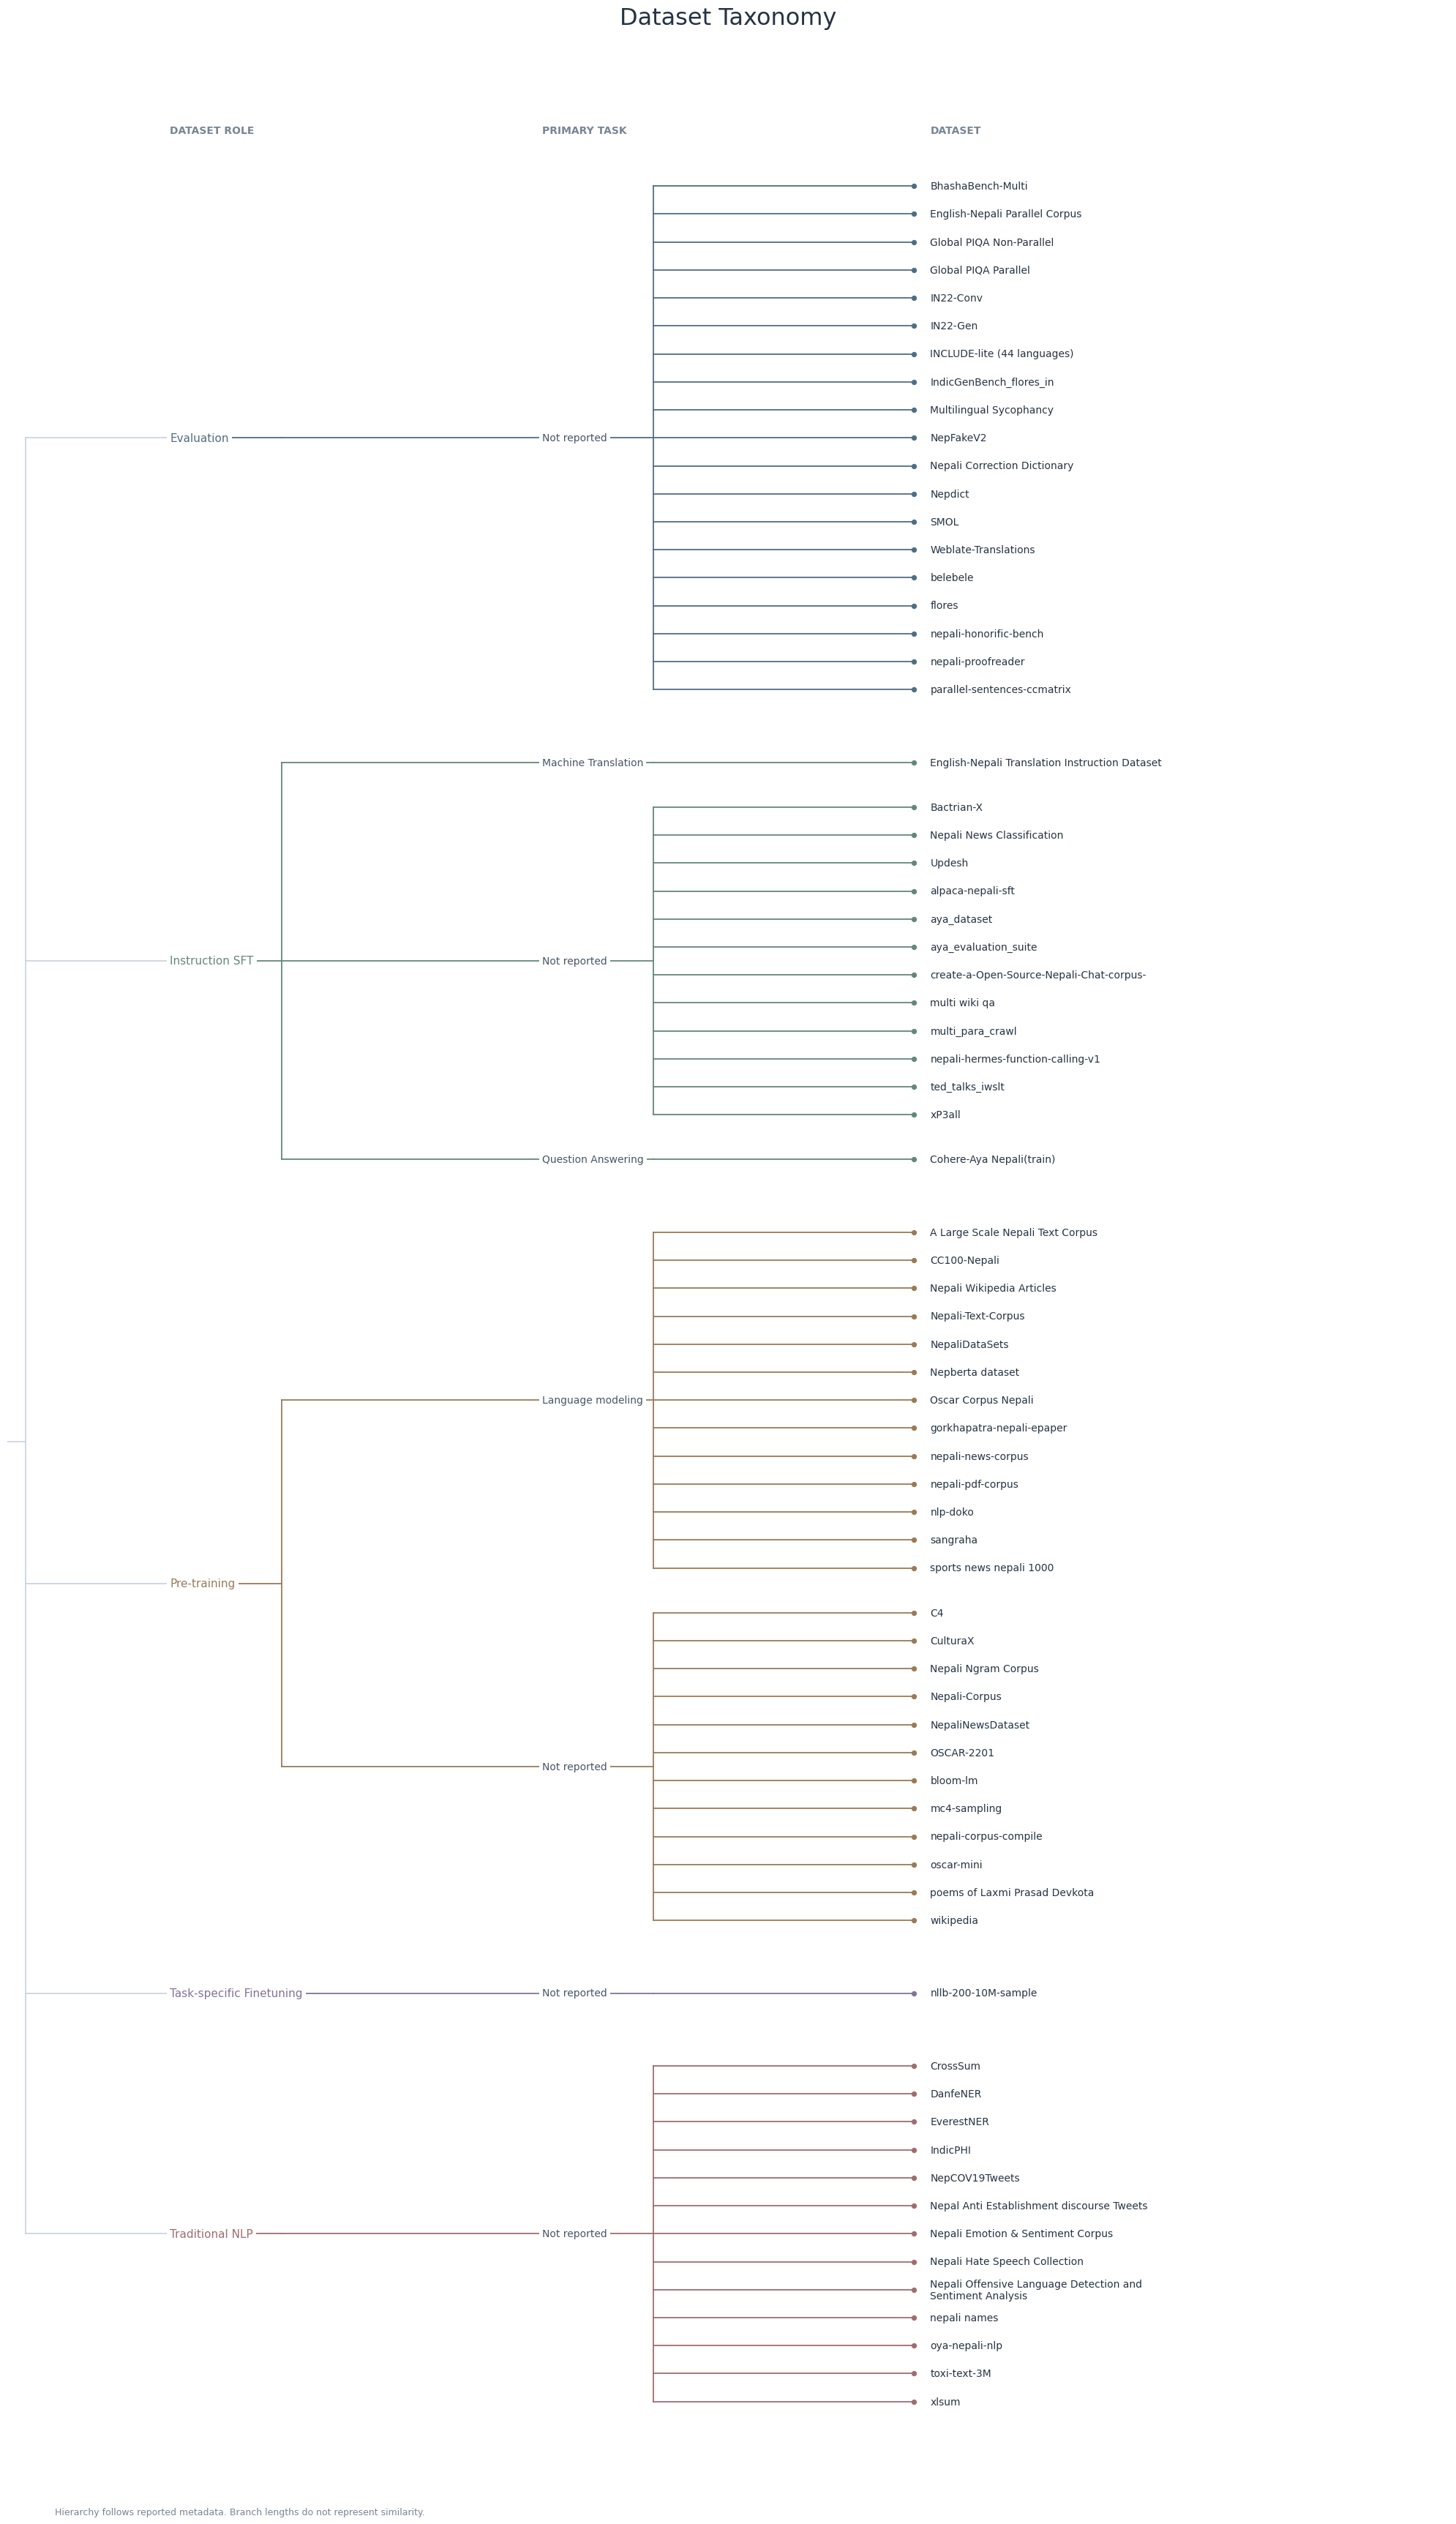

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import fill

# Prepare the hierarchy from reported metadata.
d = df.rename(columns=lambda c: c.strip())
tree = d[["Dataset Role (LLM Lifecycle)", "Primary Task", "Dataset Name"]].copy()
tree.columns = ["Role", "Task", "Dataset"]

missing = {"", "na", "n/a", "none", "nan", "unknown",
           "not specified", "not reported", "-", "—"}

for col in tree:
    tree[col] = tree[col].astype("string").str.strip()
    tree[col] = tree[col].mask(tree[col].str.lower().isin(missing))

tree = (
    tree.dropna(subset=["Role", "Dataset"])
    .fillna({"Task": "Not reported"})
    .drop_duplicates()
    .sort_values(["Role", "Task", "Dataset"])
)

if tree.empty:
    print("No dataset roles available to build the taxonomy.")
else:
    # Assign leaf positions, leaving space between branches.
    branches, cursor = [], 0
    for role, role_rows in tree.groupby("Role", sort=True):
        tasks = []
        for task, task_rows in role_rows.groupby("Task", sort=True):
            leaves = []
            for name in task_rows["Dataset"]:
                leaves.append((name, -cursor))
                cursor += 1
            tasks.append((task, np.mean([y for _, y in leaves]), leaves))
            cursor += 0.6
        branches.append((role, np.mean([y for _, y, _ in tasks]), tasks))
        cursor += 1.0

    palette = ["#526D82", "#64877B", "#997B59",
               "#84739B", "#A16C70", "#668796"]

    with plt.rc_context({"font.family": "DejaVu Sans", "pdf.fonttype": 42}):
        fig, ax = plt.subplots(figsize=(20, max(7, cursor * 0.40 + 2)))

        def connect(parent_x, parent_y, child_x, child_ys, color):
            elbow = parent_x + 0.48
            ax.plot([parent_x, elbow], [parent_y, parent_y],
                    color=color, lw=1.3, zorder=1)
            ax.plot([elbow, elbow], [min(child_ys), max(child_ys)],
                    color=color, lw=1.3, zorder=1)
            for y in child_ys:
                ax.plot([elbow, child_x], [y, y],
                        color=color, lw=1.3, zorder=1)

        def label(x, y, text, width, color, size=10):
            ax.text(
                x, y, fill(str(text), width),
                ha="left", va="center", fontsize=size, color=color,
                bbox=dict(facecolor="white", edgecolor="none", pad=3),
                zorder=3
            )

        role_ys = [y for _, y, _ in branches]
        connect(-1.1, np.mean(role_ys), 0, role_ys, "#CBD5E1")

        for i, (role, role_y, tasks) in enumerate(branches):
            color = palette[i % len(palette)]
            connect(0, role_y, 1.6, [y for _, y, _ in tasks], color)
            label(0, role_y, role, 26, color, 11)

            for task, task_y, leaves in tasks:
                connect(1.6, task_y, 3.2, [y for _, y in leaves], color)
                label(1.6, task_y, task, 26, "#475569")
                for name, y in leaves:
                    ax.scatter(3.2, y, s=18, color=color, zorder=4)
                    label(3.27, y, name, 48, "#253443")

        for x, heading in [(0, "DATASET ROLE"),
                           (1.6, "PRIMARY TASK"), (3.27, "DATASET")]:
            ax.text(x, 2, heading, fontsize=10, fontweight="bold",
                    color="#788594", va="center")

        ax.set_xlim(-0.7, 5.5)
        ax.set_ylim(-cursor + 0.5, 3)
        ax.axis("off")
        fig.suptitle("Dataset Taxonomy", fontsize=23,
                     fontweight="medium", color="#253443", y=0.995)
        fig.text(
            0.04, 0.008,
            "Hierarchy follows reported metadata. Branch lengths do not represent similarity.",
            fontsize=9, color="#788594"
        )
        fig.tight_layout(rect=(0, 0.025, 1, 0.975))

        fig.savefig("dataset_taxonomy.png", dpi=300,
                    bbox_inches="tight", facecolor="white")
        fig.savefig("dataset_taxonomy.pdf",
                    bbox_inches="tight", facecolor="white")
        plt.show()